# Are Young Nigerians Prepared for the Future of Work?

## Exploratory Data Analysis

This notebook analyses the relationship between digital access, human capital and youth labour-market outcomes in Nigeria.

The analysis examines five indicators covering 2010–2025:

* Internet use
* Youth literacy
* Youth unemployment
* Youth labour-force participation
* ICT service exports

The study explores trends, descriptive statistics, correlations and regression relationships to assess whether Nigeria's expansion in digital access has been accompanied by improvements in youth labour-market outcomes.

Important: The analysis identifies associations rather than causal effects. Differences in data availability across indicators are also considered when interpreting the results.


In [ ]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 310.8 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.5 MB 310.8 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.5 MB 310.8 kB/s eta 0:00:29
   -- ------------------------------------- 0.5/9.5 MB 310.8 kB/s eta 0:00:


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Data Loading and Preparation

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("../data/nigeria_indicators.csv")

In [ ]:
df.head()

,Year,Individuals using the Internet (% of population),"Literacy rate, youth total (% of people ages 15-24)","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)","Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)","ICT service exports (BoP, current US$)",Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,2010,11.5,..,7.861,69.387,47427758.94,NaN,NaN,NaN,NaN,15.0,NaN
1,2011,13.80000019,..,7.896,69.536,49982616.43,NaN,NaN,NaN,NaN,NaN,NaN
2,2012,16.10000038,..,7.861,69.048,50519326.35,NaN,NaN,NaN,NaN,NaN,NaN
3,2013,19.10000038,79.16,7.713,68.211,51656515.83,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,21,..,8.044,68.091,53640000.00,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.iloc[:, :6]

In [ ]:
df = df.replace("..", pd.NA)

In [ ]:
df["Individuals using the Internet (% of population)"] = pd.to_numeric(
    df["Individuals using the Internet (% of population)"]
)

df["Literacy rate, youth total (% of people ages 15-24)"] = pd.to_numeric(
    df["Literacy rate, youth total (% of people ages 15-24)"]
)

In [ ]:
df.head()

,Year,Individuals using the Internet (% of population),"Literacy rate, youth total (% of people ages 15-24)","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)","Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)","ICT service exports (BoP, current US$)"
0,2010,11.5,NaN,7.861,69.387,47427758.94
1,2011,13.8,NaN,7.896,69.536,49982616.43
2,2012,16.1,NaN,7.861,69.048,50519326.35
3,2013,19.1,79.16,7.713,68.211,51656515.83
4,2014,21.0,NaN,8.044,68.091,53640000.00


In [ ]:
df.dtypes

Year                                                                                      int64
Individuals using the Internet (% of population)                                        float64
Literacy rate, youth total (% of people ages 15-24)                                     float64
Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)    float64
Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)         float64
ICT service exports (BoP, current US$)                                                  float64
dtype: object

2. Trend Analysis

<Axes: xlabel='Year'>

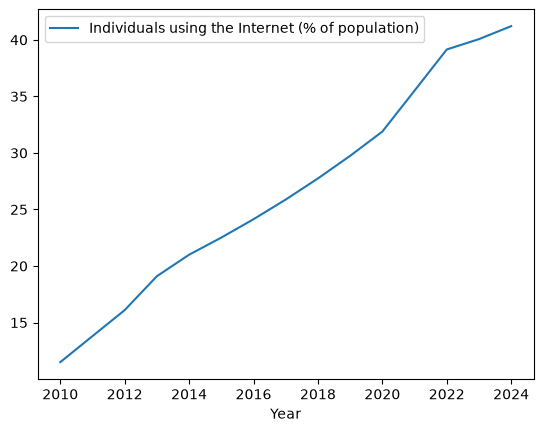

In [ ]:
df.plot(
    x="Year",
    y="Individuals using the Internet (% of population)",
    kind="line"
)

<Axes: xlabel='Year'>

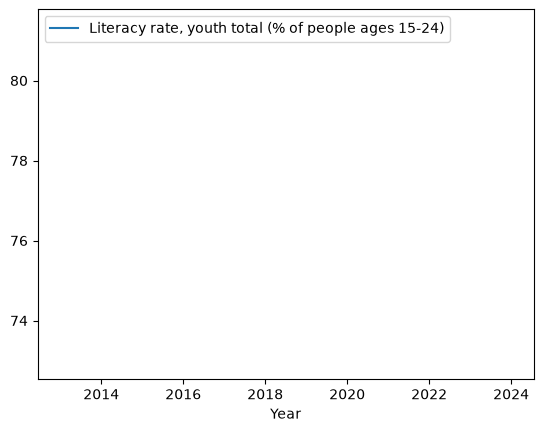

In [ ]:
df.plot(
    x="Year",
    y="Literacy rate, youth total (% of people ages 15-24)",
    kind="line"
)

In [ ]:
df[["Year", "Literacy rate, youth total (% of people ages 15-24)"]].dropna()

,Year,"Literacy rate, youth total (% of people ages 15-24)"
3,2013,79.160000
6,2016,72.959999
11,2021,73.669998
14,2024,81.360001


<Axes: xlabel='Year'>

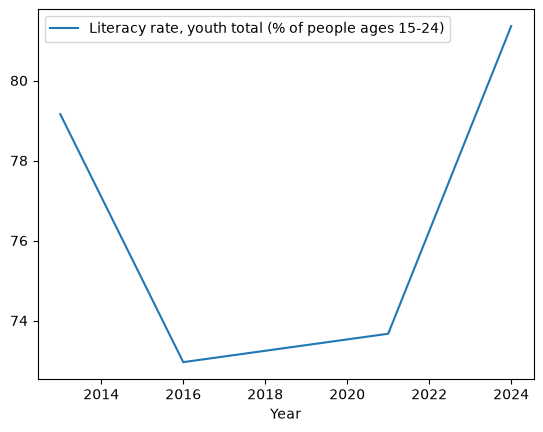

In [ ]:
literacy = df[[
    "Year",
    "Literacy rate, youth total (% of people ages 15-24)"
]].dropna()

literacy.plot(
    x="Year",
    y="Literacy rate, youth total (% of people ages 15-24)",
    kind="line"
)

<Axes: xlabel='Year'>

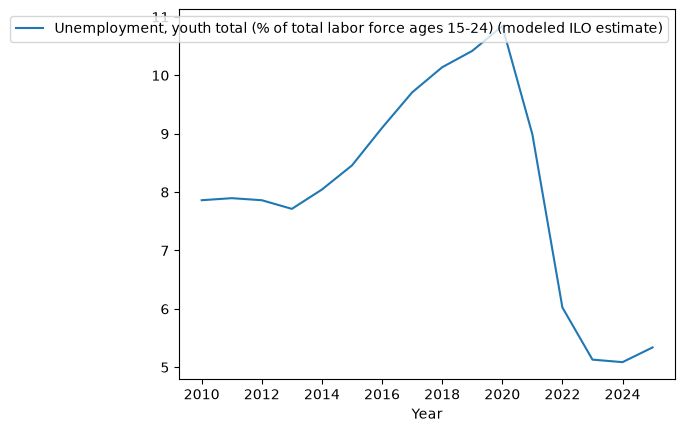

In [ ]:
df.plot(
    x="Year",
    y="Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)",
    kind="line"
)

<Axes: xlabel='Year'>

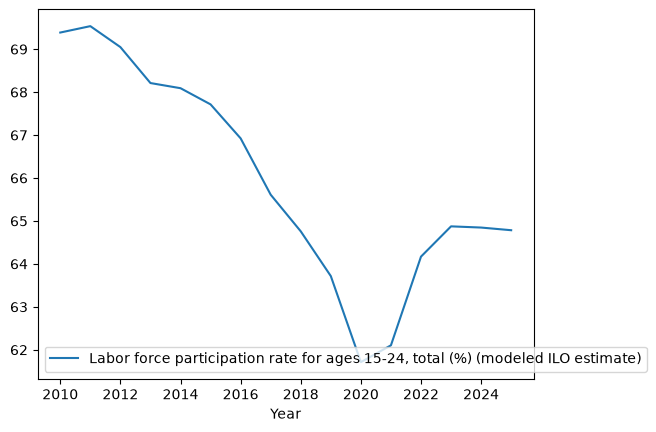

In [ ]:
df.plot(
    x="Year",
    y="Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",
    kind="line"
)

<Axes: xlabel='Year'>

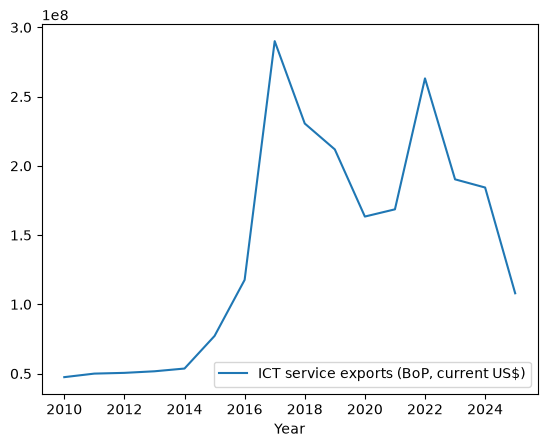

In [ ]:
df.plot(
    x="Year",
    y="ICT service exports (BoP, current US$)",
    kind="line"
)

<Axes: xlabel='Individuals using the Internet (% of population)', ylabel='Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)'>

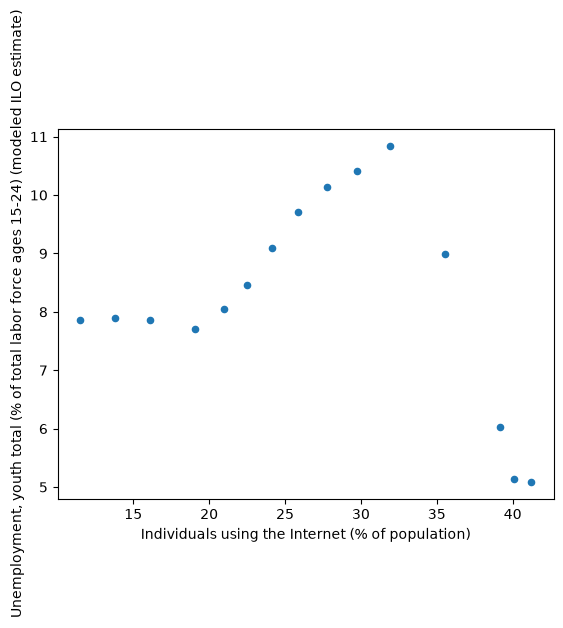

In [ ]:
df.plot(
    x="Individuals using the Internet (% of population)",
    y="Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)",
    kind="scatter"
)

3. Descriptive Statistics

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/nigeria_indicators.csv")

In [6]:
df = df.iloc[:, :6]
df = df.replace("..", pd.NA)

df["Individuals using the Internet (% of population)"] = pd.to_numeric(
    df["Individuals using the Internet (% of population)"]
)

df["Literacy rate, youth total (% of people ages 15-24)"] = pd.to_numeric(
    df["Literacy rate, youth total (% of people ages 15-24)"]
)

4. Correlation Analysis

In [7]:
relationship = df[[
    "Individuals using the Internet (% of population)",
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]].dropna()

In [8]:
relationship.corr().iloc[0, 1]

np.float64(-0.29989279562827265)

In [9]:
relationship2 = df[[
    "Individuals using the Internet (% of population)",
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)"
]].dropna()

In [10]:
relationship2.corr().iloc[0, 1]

np.float64(-0.8310413566679299)

In [11]:
relationship3 = df[[
    "Individuals using the Internet (% of population)",
    "Literacy rate, youth total (% of people ages 15-24)"
]].dropna()

In [12]:
relationship3.corr().iloc[0, 1]

np.float64(0.24441700459782129)

In [13]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Year,Individuals using the Internet (% of population),"Literacy rate, youth total (% of people ages 15-24)","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)","Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)","ICT service exports (BoP, current US$)"
Year,1.000000,0.996053,0.227610,-0.364658,-0.823324,0.640482
Individuals using the Internet (% of population),0.996053,1.000000,0.244417,-0.299893,-0.831041,0.738651
"Literacy rate, youth total (% of people ages 15-24)",0.227610,0.244417,1.000000,-0.923443,0.260421,-0.014106
"Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)",-0.364658,-0.299893,-0.923443,1.000000,-0.163956,0.125803
"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",-0.823324,-0.831041,0.260421,-0.163956,1.000000,-0.724537
"ICT service exports (BoP, current US$)",0.640482,0.738651,-0.014106,0.125803,-0.724537,1.000000


In [14]:
df[[
    "Year",
    "Individuals using the Internet (% of population)",
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)"
]].dropna()

,Year,Individuals using the Internet (% of population),"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)"
0,2010,11.500000,69.387
1,2011,13.800000,69.536
2,2012,16.100000,69.048
3,2013,19.100000,68.211
4,2014,21.000000,68.091
5,2015,22.514200,67.714
6,2016,24.137501,66.923
7,2017,25.877899,65.611
8,2018,27.743700,64.758
9,2019,29.744101,63.716


5. Year-to-Year Changes

In [15]:
changes = df[[
    "Year",
    "Individuals using the Internet (% of population)",
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)"
]].dropna().copy()

changes["Internet_change"] = changes[
    "Individuals using the Internet (% of population)"
].diff()

changes["Labour_participation_change"] = changes[
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)"
].diff()

changes

,Year,Individuals using the Internet (% of population),"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",Internet_change,Labour_participation_change
0,2010,11.500000,69.387,NaN,NaN
1,2011,13.800000,69.536,2.300000,0.149
2,2012,16.100000,69.048,2.300000,-0.488
3,2013,19.100000,68.211,3.000000,-0.837
4,2014,21.000000,68.091,1.900000,-0.120
5,2015,22.514200,67.714,1.514200,-0.377
6,2016,24.137501,66.923,1.623301,-0.791
7,2017,25.877899,65.611,1.740398,-1.312
8,2018,27.743700,64.758,1.865801,-0.853
9,2019,29.744101,63.716,2.000401,-1.042


In [16]:
changes[[
    "Internet_change",
    "Labour_participation_change"
]].corr().iloc[0, 1]

np.float64(0.33784871552234025)

In [17]:
changes2 = df[[
    "Year",
    "Individuals using the Internet (% of population)",
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]].dropna().copy()

changes2["Internet_change"] = changes2[
    "Individuals using the Internet (% of population)"
].diff()

changes2["Unemployment_change"] = changes2[
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
].diff()

In [18]:
changes2[[
    "Internet_change",
    "Unemployment_change"
]].corr().iloc[0, 1]

np.float64(-0.6616350705728283)

In [19]:
relationship4 = df[[
    "ICT service exports (BoP, current US$)",
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]].dropna()

relationship4.corr().iloc[0, 1]

np.float64(0.12580300474449238)

In [20]:
relationship5 = df[[
    "ICT service exports (BoP, current US$)",
    "Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)"
]].dropna()

relationship5.corr().iloc[0, 1]

np.float64(-0.7245368217557592)

In [21]:
corr = df.corr(numeric_only=True)

In [22]:
corr = df.corr(numeric_only=True)

corr

,Year,Individuals using the Internet (% of population),"Literacy rate, youth total (% of people ages 15-24)","Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)","Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)","ICT service exports (BoP, current US$)"
Year,1.000000,0.996053,0.227610,-0.364658,-0.823324,0.640482
Individuals using the Internet (% of population),0.996053,1.000000,0.244417,-0.299893,-0.831041,0.738651
"Literacy rate, youth total (% of people ages 15-24)",0.227610,0.244417,1.000000,-0.923443,0.260421,-0.014106
"Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)",-0.364658,-0.299893,-0.923443,1.000000,-0.163956,0.125803
"Labor force participation rate for ages 15-24, total (%) (modeled ILO estimate)",-0.823324,-0.831041,0.260421,-0.163956,1.000000,-0.724537
"ICT service exports (BoP, current US$)",0.640482,0.738651,-0.014106,0.125803,-0.724537,1.000000


6. Regression Analysis

In [23]:
reg_data = df[[
    "Individuals using the Internet (% of population)",
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]].dropna()

In [24]:
reg_data

,Individuals using the Internet (% of population),"Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
0,11.500000,7.861
1,13.800000,7.896
2,16.100000,7.861
3,19.100000,7.713
4,21.000000,8.044
5,22.514200,8.457
6,24.137501,9.100
7,25.877899,9.707
8,27.743700,10.138
9,29.744101,10.418


In [26]:
!pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.3 MB 2.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.3 MB 3.0 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/11.3 MB 3.7 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 4.0 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.3 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.3 MB 3.9 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.3 MB 4.1 MB/s eta 0:00:02
   ----------------------------- ---------- 8.4/11.3 MB 4.3 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 4.5 MB/s eta 0:00:01
   ------------------------------------- -- 10.7/11.3 MB 4.6 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import statsmodels.api as sm

In [28]:
X = reg_data["Individuals using the Internet (% of population)"]
Y = reg_data["Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"]

In [29]:
X = sm.add_constant(X)

In [30]:
model = sm.OLS(Y, X).fit()

In [31]:
print(model.summary())

                                                             OLS Regression Results                                                             
Dep. Variable:     Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)   R-squared:                       0.090
Model:                                                                                              OLS   Adj. R-squared:                  0.020
Method:                                                                                   Least Squares   F-statistic:                     1.285
Date:                                                                                  Thu, 10 Sep 2026   Prob (F-statistic):              0.277
Time:                                                                                          14:44:55   Log-Likelihood:                -28.622
No. Observations:                                                                                    15   AIC:                    

7. Multicollinearity Check

In [32]:
reg_data2 = df[[
    "Individuals using the Internet (% of population)",
    "ICT service exports (BoP, current US$)",
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]].dropna()

In [33]:
X2 = reg_data2[[
    "Individuals using the Internet (% of population)",
    "ICT service exports (BoP, current US$)"
]]

Y2 = reg_data2[
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]

In [34]:
X2 = sm.add_constant(X2)

In [35]:
model2 = sm.OLS(Y2, X2).fit()

In [36]:
print(model2.summary())

                                                             OLS Regression Results                                                             
Dep. Variable:     Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)   R-squared:                       0.306
Model:                                                                                              OLS   Adj. R-squared:                  0.191
Method:                                                                                   Least Squares   F-statistic:                     2.648
Date:                                                                                  Thu, 10 Sep 2026   Prob (F-statistic):              0.112
Time:                                                                                          14:49:36   Log-Likelihood:                -26.587
No. Observations:                                                                                    15   AIC:                    

8. Autocorrelation Test

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [38]:
X_vif = sm.add_constant(reg_data2[[
    "Individuals using the Internet (% of population)",
    "ICT service exports (BoP, current US$)"
]])

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif

,Variable,VIF
0,const,1.000000
1,Individuals using the Internet (% of population),2.200731
2,"ICT service exports (BoP, current US$)",2.200731


In [39]:
reg_data2["ICT_exports_millions"] = (
    reg_data2["ICT service exports (BoP, current US$)"] / 1_000_000
)

reg_data2[["ICT service exports (BoP, current US$)", "ICT_exports_millions"]].head()

,"ICT service exports (BoP, current US$)",ICT_exports_millions
0,47427758.94,47.427759
1,49982616.43,49.982616
2,50519326.35,50.519326
3,51656515.83,51.656516
4,53640000.00,53.640000


In [40]:
X3 = reg_data2[[
    "Individuals using the Internet (% of population)",
    "ICT_exports_millions"
]]

Y3 = reg_data2[
    "Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)"
]

X3 = sm.add_constant(X3)

model3 = sm.OLS(Y3, X3).fit()

print(model3.summary())

                                                             OLS Regression Results                                                             
Dep. Variable:     Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)   R-squared:                       0.306
Model:                                                                                              OLS   Adj. R-squared:                  0.191
Method:                                                                                   Least Squares   F-statistic:                     2.648
Date:                                                                                  Thu, 10 Sep 2026   Prob (F-statistic):              0.112
Time:                                                                                          15:11:14   Log-Likelihood:                -26.587
No. Observations:                                                                                    15   AIC:                    

9. HAC Robust Standard Errors

In [41]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_test = acorr_breusch_godfrey(model3, nlags=1)

print("LM statistic:", bg_test[0])
print("LM p-value:", bg_test[1])

LM statistic: 5.020320555613079
LM p-value: 0.025051530922917595


C:\Users\HP\AppData\Local\Temp\ipykernel_984\254442093.py:3: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  bg_test = acorr_breusch_godfrey(model3, nlags=1)


In [42]:
model3_robust = model3.get_robustcov_results(cov_type="HAC", maxlags=1)

print(model3_robust.summary())

                                                             OLS Regression Results                                                             
Dep. Variable:     Unemployment, youth total (% of total labor force ages 15-24) (modeled ILO estimate)   R-squared:                       0.306
Model:                                                                                              OLS   Adj. R-squared:                  0.191
Method:                                                                                   Least Squares   F-statistic:                     4.292
Date:                                                                                  Thu, 10 Sep 2026   Prob (F-statistic):             0.0393
Time:                                                                                          15:40:31   Log-Likelihood:                -26.587
No. Observations:                                                                                    15   AIC:                    